# 2. Índice de Convergencia

Los datos usados para la Union Europea los tomaremos de los datos de los paises de la UE14 (-GB) ante la falta de acceso a loa daros de *Reino Unido de Gran Bretaña e Irlanda del Norte* pues al momento del estudio el acceso a dicha información fue escaso.

Tomé los datos del PIB de UE14 desde el año en el que Polonia entró a la UE (2004).

Adicionalmente los restantes paises de *Grupo de Visegrád* (CZ, HU, SK) que entraron el mismo año a la UE, los tomaré como *Grupo de control* y *comparativo regional*.

La formula seguida es: 


$$\text{Índice} = \left( \frac{\text{PIBpc país}}{\text{PIBpc promedio UE-14}} \right) \times 100$$

Tomamos como 100% de convergencia al promedio del crecimiento del PIB UE-14 del 2002 hasta el 2022. 

Cada pais del V4 será analizado.

In [ ]:
import sys
import os
from scipy import stats

# ruta relativa robusta
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SRC_PATH = os.path.join(PROJECT_ROOT, "src")

sys.path.insert(0, SRC_PATH)

# print(f"Project root: {PROJECT_ROOT}")
# print(f"src: {SRC_PATH}")
# print(f"Existe: {os.path.exists(os.path.join(SRC_PATH, 'config.py'))}")

from config import UE14, V4, COLORES_V4, NOMBRES_PAIS, AÑO_INICIO_DEFAULT, AÑO_FIN_DEFAULT
from db_utils import load_convergencia_data
from plotting_utils import setup_plot_style, save_figure

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

setup_plot_style()
# print("Todo listo")

In [13]:
# import os
# print(f"cwd: {os.getcwd()}")
# print(f"../../src/config.py existe: {os.path.exists('../../src/config.py')}")

In [16]:
# Cargar datos
df = load_convergencia_data(paises=UE14 + V4, años=list(range(AÑO_INICIO_DEFAULT, AÑO_FIN_DEFAULT + 1)))


# Cálculo promedio UE-14 por año
promedio_ue14 = df[df['pais'].isin(UE14)].groupby('año')['valor'].mean()\

# Cálcular índice de convergencia a países V4
convergencia = pd.DataFrame()
for pais in V4:
    pais_data = df[df['pais'] == pais].set_index('año')['valor']
    convergencia[pais] = (pais_data / promedio_ue14 * 100).round(2)

print("Convergencia Index (% del promedio UE-14):")
print(convergencia)

Convergencia Index (% del promedio UE-14):
         PL     CZ     HU     SK
año                             
2004  40.28  62.96  48.80  45.46
2005  40.30  63.80  49.42  47.78
2006  39.88  62.54  48.15  49.41
2007  41.89  65.20  47.49  52.61
2008  44.04  66.66  49.63  56.55
2009  47.68  68.16    NaN  56.68
2010  50.58  67.56  52.27  60.73
2011  52.91  67.79  53.32  60.76
2012  54.33  67.48  53.16  61.88
2013  54.04  68.65  54.38  62.08
2014  54.75  70.54  55.46  62.58
2015  55.19  69.97  55.08  61.66
2016  55.27  71.36  54.90  58.19
2017  56.18  73.76  55.34  56.31
2018  57.88  75.15  57.70  56.36
2019  60.28  77.47  59.82  57.07
2020  63.29  77.22  60.16  59.70
2021  62.76  73.07    NaN  58.64
2022  61.86  71.26  60.02  56.09
2023  62.21  73.71  61.05  60.04


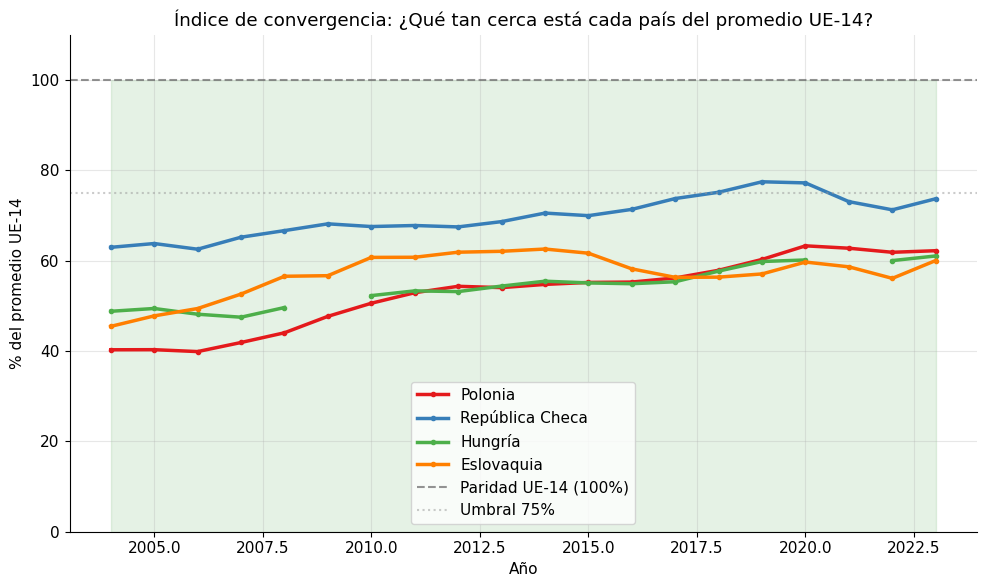

In [19]:
# Gráfica del índice de convergencia
fig, ax = plt.subplots(figsize=(10, 6))

for pais in V4:
    ax.plot(convergencia.index, convergencia[pais], 
            color=COLORES_V4[pais], linewidth=2.5, 
            label=NOMBRES_PAIS[pais], marker='o', markersize=3)
 
ax.axhline(y=100, color='#666666', linestyle='--', alpha=0.7, label='Paridad UE-14 (100%)')
ax.axhline(y=75, color='#999999', linestyle=':', alpha=0.5, label='Umbral 75%')
ax.fill_between(convergencia.index, 0, 100, alpha=0.1, color='green')

ax.set_title('Índice de convergencia: ¿Qué tan cerca está cada país del promedio UE-14?')
ax.set_xlabel('Año')
ax.set_ylabel('% del promedio UE-14')
ax.legend()
ax.set_ylim(0, 110)

plt.tight_layout()
save_figure(fig, '02_indice_convergencia.png')
plt.show()

## Interpretación del gráfico

**100%** El promedio UE-14 como techo a alcanzar en la grafica por los paises del V4.

**Umbral 75%**: Umbral de convergencia parcial fijado por  normativa política y administrativa de la Unión Europea.

In [8]:
# Tabla resumen de convergencia
resumen = pd.DataFrame()
for pais in V4:
    resumen.loc[pais, '2004'] = convergencia[pais].iloc[0]
    resumen.loc[pais, '2023'] = convergencia[pais].iloc[-1]
    resumen.loc[pais, 'Cambio (pp)'] = convergencia[pais].iloc[-1] - convergencia[pais].iloc[0]
    resumen.loc[pais, 'Cambio (%)'] = ((convergencia[pais].iloc[-1] / convergencia[pais].iloc[0]) - 1) * 100

print("Resumen de convergencia:")
print(resumen.round(2))

Resumen de convergencia:
     2004   2023  Cambio (pp)  Cambio (%)
PL  40.28  62.21        21.93       54.44
CZ  62.96  73.71        10.75       17.07
HU  48.80  61.05        12.25       25.10
SK  45.46  60.04        14.58       32.07


# Detalles
Falta de datos:

    - HU 2029: Quebra tecnica (PIB -6.7%.), rescate del FMI y revisión metodológica posterior. Muchas bases de datos europeas (como Eurostat) cortaron o encadenaron las series de PIB per cápita en paridad de poder adquisitivo (PPA) tomando el año 2010 como nueva base (coincidiendo con la llegada de Viktor Orbán al poder). Al cambiar la fórmula del año base, los datos anteriores a 2010 a veces no se cargan automáticamente si no se busca la serie histórica "retrapolada". https://www.osw.waw.pl/en/publikacje/osw-commentary/2026-03-20/stable-stagnation-hungarys-economic-standing-after-16-years
    - HU 2021: El problema con los datos: Para medir el PIB real y comparar los índices de convergencia, Eurostat y la Oficina Central de Estadística de Hungría (KSH) aplican "Revisiones de Referencia" (Benchmark Revisions) cada ciertos años para actualizar las ponderaciones de consumo tras shocks severos (como el confinamiento del 2020).Impacto en tu análisis: Las cifras macroeconómicas preliminares de 2021 se modificaron sustancialmente meses después debido a las distorsiones de la inflación y las ayudas estatales. Si tu script de Python o tu base de datos local está apuntando a una serie de datos rígida (por ejemplo, PIB base constante anterior), el año 2021 suele quedar huérfano porque los organismos internacionales mudaron los registros oficiales indexados a la nueva metodología estandarizada.

    - Paso por alto que el umbral del 75% de convergencia la UE los definió oficialmenteen terminos de  PIB per cápita (en Paridad de Poder Adquisitivo) y mi analisis tomó el PIB per capita nominal.